In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

sys.path.append('src')

from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 75

In [2]:
import scanpy as sc
from scipy.sparse import csr_matrix

from anndata import AnnData
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

from src.cellina_graph._spatial_utils import spatial_neighbors
from cellina_graph import CellinaModel

In [3]:
# adata = sc.read_h5ad("../dsa/notebooks/synthetic_eval/synthetic_spatial_adata.h5ad")
# adata.var.index = adata.var['gene_name-new']
# domains_key = "region"
# labels_key = 'cell_type'

In [4]:
slide_id = 232

In [5]:
adata = sc.read(
    f"../../data/crc_wt_cosmx/crc_{slide_id}.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/{slide_id}.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [6]:
adata.X

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 7561312 stored elements and shape (111989, 2000)>

In [7]:
# sc.pl.spatial(adata, color=[domains_key, labels_key], spot_size=50)

In [8]:
n_neighbors = 50
# 10 is a good default option
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [9]:
CellinaModel.setup_anndata(adata,
                           batch_key=None,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           layer='counts',
                           spatial_connectivities_key='spatial_connectivities'
                           )
model = CellinaModel(adata,
                     n_latent=20,
                     convolution_type='gat',
                     classifier_lambda=1,
                     discriminator_lambda=1,
                     n_layers=3,
                     link_prediction_weight=5, # NOTE Not sure if this is needed, nor if it works when combined with the other losses...
                     condition_on_intrinsic=False
                     )

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [10]:
model.train(max_epochs=100,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=5,
            early_stopping_monitor='vae_loss_validation',
            train_size=0.9,
            validation_size=0.1,
            # default_root_dir='scvi_log/',
            plan_kwargs={'lr': 0.001,
                         'weight_decay': 0.0001,
                         'normalize_losses': True,
                        #  "scale_adversarial_loss": "normalized"
                         },
            enable_checkpointing=True,
            # callbacks=[
            #     SaveCheckpoint(monitor="validation_loss",
            #                    load_best_on_end=True,
            #                    dirpath=f'scvi_log/synthetic/',
            #                    filename='test1'),
            # ],
            batch_size=512,
            devices=[1]
            )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


Training:   0%|          | 0/100 [00:00<?, ?it/s]

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 23155. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 23884. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 23349. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 318.389. Signaling Trainer to stop.


In [11]:
list(model.history_.keys())

['validation_loss',
 'elbo_validation',
 'reconstruction_loss_validation',
 'kl_local_validation',
 'kl_global_validation',
 'vae_loss_validation',
 'classifier_loss_raw_validation',
 'classifier_loss_validation',
 'classifier_accuracy_validation',
 'fool_loss_raw_validation',
 'fool_loss_validation',
 'fool_accuracy_validation',
 'edge_prediction_loss_validation',
 'edge_prediction_accuracy_validation',
 'discriminator_loss_validation',
 'discriminator_accuracy_validation',
 'ema_vae_init',
 'ema_clf_init',
 'ema_fool_init',
 'ema_edge_init',
 'discriminator_loss_train',
 'discriminator_accuracy_train',
 'train_loss',
 'scale_classifier_train',
 'scale_fool_train',
 'scale_edge_train',
 'elbo_train',
 'reconstruction_loss_train',
 'kl_local_train',
 'kl_global_train',
 'vae_loss_train',
 'classifier_loss_raw_train',
 'classifier_loss_train',
 'classifier_accuracy_train',
 'fool_loss_raw_train',
 'fool_loss_train',
 'fool_accuracy_train',
 'edge_prediction_loss_train',
 'edge_predictio

<Axes: xlabel='epoch'>

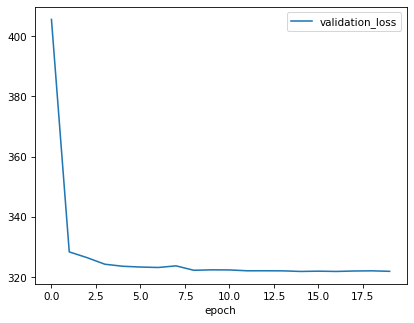

In [12]:
model.history_['validation_loss'].plot()

<Axes: xlabel='epoch'>

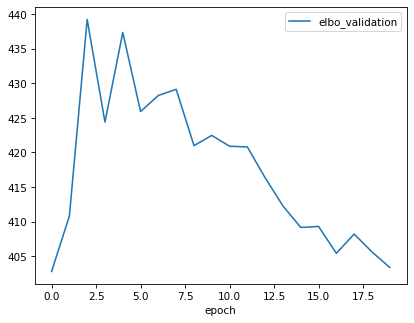

In [13]:
model.history_['elbo_validation'].plot()

<Axes: xlabel='epoch'>

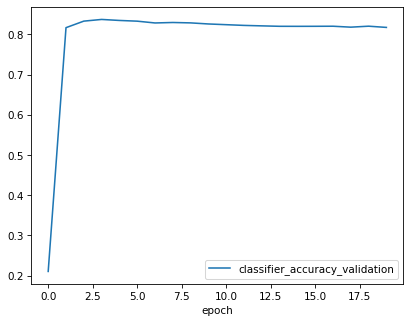

In [14]:
model.history_['classifier_accuracy_validation'].plot()

<Axes: xlabel='epoch'>

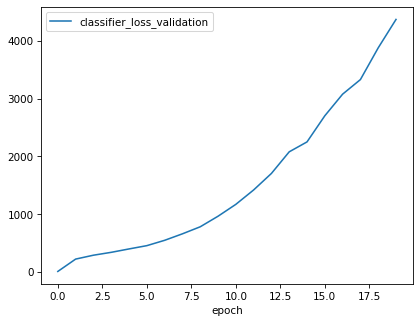

In [15]:
model.history_['classifier_loss_validation'].plot()

<Axes: xlabel='epoch'>

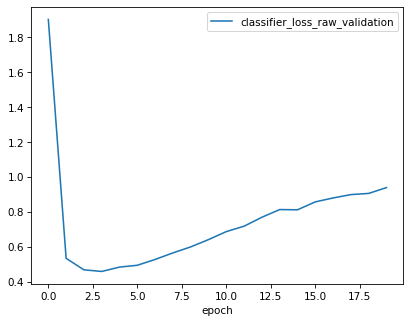

In [16]:
model.history_['classifier_loss_raw_validation'].plot()

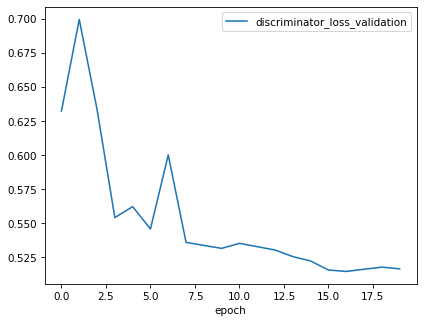

In [17]:
if 'discriminator_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['discriminator_loss_validation'].plot()

In [18]:
model.history_.keys()

dict_keys(['validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'edge_prediction_accuracy_validation', 'discriminator_loss_validation', 'discriminator_accuracy_validation', 'ema_vae_init', 'ema_clf_init', 'ema_fool_init', 'ema_edge_init', 'discriminator_loss_train', 'discriminator_accuracy_train', 'train_loss', 'scale_classifier_train', 'scale_fool_train', 'scale_edge_train', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train', 'edge_prediction_accuracy_train'])

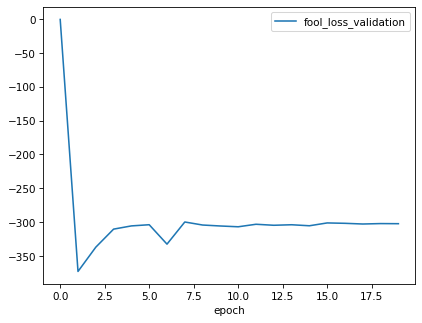

In [19]:
if 'fool_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['fool_loss_validation'].plot()

<Axes: xlabel='epoch'>

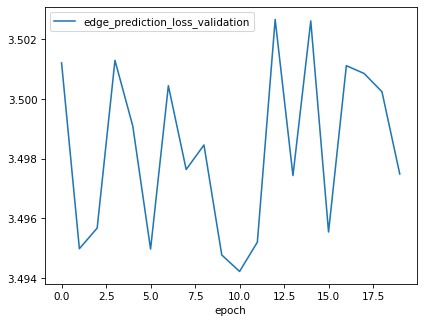

In [20]:
model.history_['edge_prediction_loss_validation'].plot()

In [21]:
model.history_.keys()

dict_keys(['validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'edge_prediction_accuracy_validation', 'discriminator_loss_validation', 'discriminator_accuracy_validation', 'ema_vae_init', 'ema_clf_init', 'ema_fool_init', 'ema_edge_init', 'discriminator_loss_train', 'discriminator_accuracy_train', 'train_loss', 'scale_classifier_train', 'scale_fool_train', 'scale_edge_train', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train', 'edge_prediction_accuracy_train'])

<Axes: xlabel='epoch'>

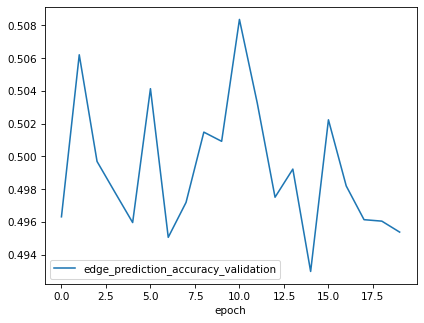

In [22]:
model.history_['edge_prediction_accuracy_validation'].plot() # NOTE: makes sense that it's not very high, since the graph is very sparse and very large.

In [23]:
adata.obsm['z'] = model.get_latent_representation(latent_key='z')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


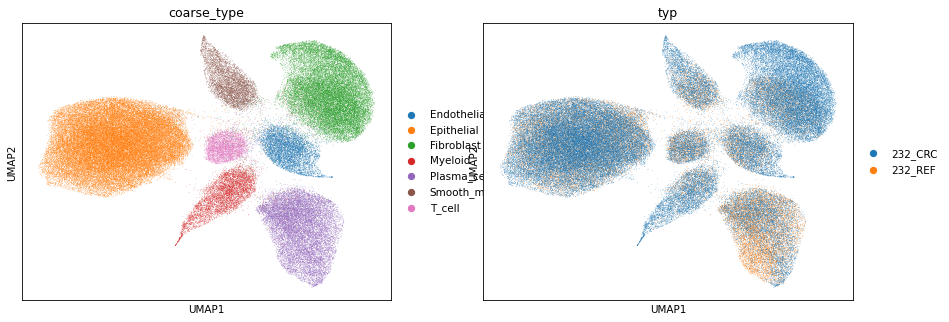

In [24]:
sc.pp.neighbors(adata, use_rep='z')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[labels_key, domains_key])

In [25]:
adata.obsm['z'].max()

14.956345

In [26]:
adata.obsm['s'] = model.get_latent_representation(latent_key='s')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


In [27]:
adata.obsm['s'].max()

5.420097

## CT

In [28]:
ct_target = 'Endothelial'

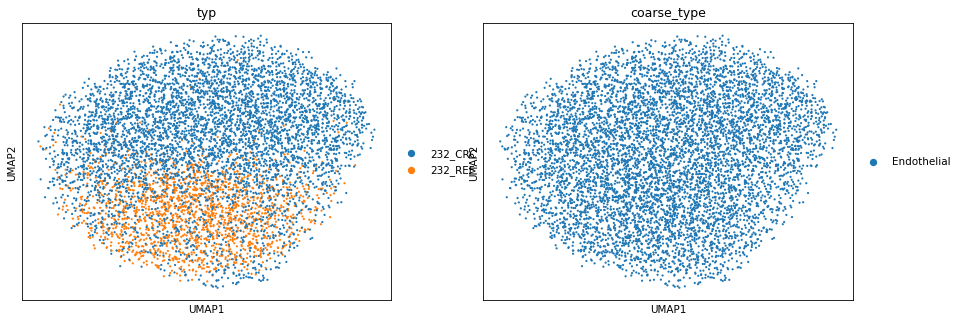

In [29]:
fib_adata = adata[adata.obs[labels_key]==ct_target]
sc.pp.neighbors(fib_adata, use_rep='s')
sc.tl.umap(fib_adata)
sc.pl.umap(fib_adata, color=[domains_key, labels_key])

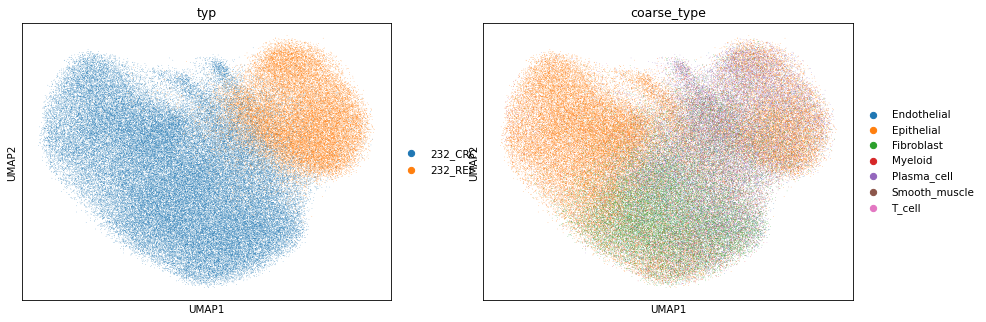

In [30]:
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[domains_key, labels_key])

## Counterfactual

In [31]:
# Counterfactual: fibroblasts in TVA with CRC neighbours
seed_mask = (adata.obs[labels_key] == ct_target) & (adata.obs[domains_key] == f'{slide_id}_REF')
nbr_mask  = adata.obs[domains_key] == f'{slide_id}_CRC'

seed_idx = np.where(seed_mask)[0]
nbr_idx  = np.where(nbr_mask)[0]

cf_s = model.get_counterfactual_latents(
    seed_idx, nbr_idx,
    n_neighbors_per_seed=10,
    latent_key='s',
    batch_size=512,
    give_mean=True
)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


In [32]:
import anndata as ad

# Subset real fibroblasts from each domain
fib_tva = adata[seed_mask].copy()
fib_crc = adata[(adata.obs[labels_key] == ct_target) & (adata.obs[domains_key] == f'{slide_id}_CRC')].copy()
fib_ref = adata[(adata.obs[labels_key] == ct_target) & (adata.obs[domains_key] == f'{slide_id}_REF')].copy()

# Build counterfactual anndata (same cells as fib_tva, but with cf spatial embedding)
fib_cf = fib_tva.copy()
fib_cf.obs[domains_key] = 'cf_REF→CRC'
fib_cf.obsm['s'] = cf_s

# Concatenate
combined = ad.concat([fib_tva, fib_crc, fib_ref, fib_cf])

# UMAP on s representation
sc.pp.neighbors(combined, use_rep='s')
sc.tl.umap(combined)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


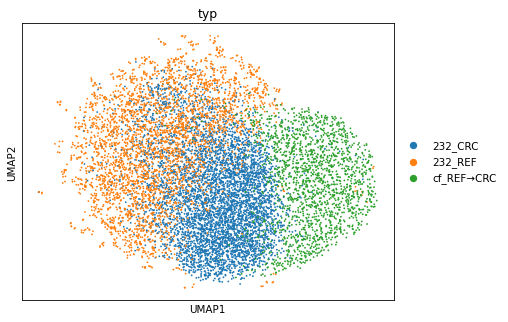

In [33]:
sc.pl.umap(combined, color=[domains_key])

In [34]:
adata.obs[domains_key].unique()

['232_REF', '232_CRC']
Categories (2, object): ['232_CRC', '232_REF']

In [35]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import numpy as np


def _cf_indices(adata, mask, model=None, use_validation=False):
    """Return cell indices matching mask, filtered to holdout/validation if available."""
    idx = np.where(mask)[0]
    if 'is_holdout' in adata.obs.columns:
        holdout = adata.obs['is_holdout'].values.astype(bool)
        return np.where(mask & holdout)[0]
    if use_validation and model is not None and hasattr(model, 'validation_indices_'):
        val_set = set(model.validation_indices_)
        return idx[np.isin(idx, list(val_set))]
    return idx


def compute_cf_logfc(
    model,
    adata,
    ref_domain,
    crc_domain,
    celltype_col='coarse_type',
    domain_col='typ',
    n_neighbors_per_seed=10,
    batch_size=512,
    min_cells=20,
    use_validation=False,
    seed=0,
    top_n=None,
):
    """
    For each cell type present in both ref_domain and crc_domain, compute:
      - REF_denoised : model-predicted expression for REF cells (real graph)
      - CRC_denoised : model-predicted expression for CRC cells (real graph)
      - CRC_CF       : counterfactual expression for REF cells wired to CRC neighbours
      - real_logfc   = mean log1p(CRC_denoised) − mean log1p(REF_denoised)
      - cf_logfc     = mean log1p(CRC_CF)       − mean log1p(REF_denoised)
    Pearson r, Spearman r are computed on the top_n genes by |real_logfc| (or all genes
    if top_n is None).

    Precision is a retrieval metric: of the top_n genes ranked by |cf_logfc|, how many
    overlap with the top_n genes ranked by |real_logfc|? Formally:
        precision = |top_n_real ∩ top_n_cf| / top_n
    This is only defined when top_n is not None; otherwise it is set to NaN.

    Parameters
    ----------
    model            : trained CellinaModel
    adata            : registered AnnData
    ref_domain       : value of domain_col for the reference tissue (e.g. '242_REF')
    crc_domain       : value of domain_col for the CRC tissue    (e.g. '242_CRC')
    celltype_col     : obs column with cell-type labels
    domain_col       : obs column with domain/tissue labels
    n_neighbors_per_seed : donors to wire per seed cell (None = all CRC cells)
    batch_size       : loader batch size
    min_cells        : skip cell types with fewer than this many cells in either domain
    use_validation   : if True and no is_holdout column, restrict to model.validation_indices_
    seed             : RNG seed for neighbour sampling
    top_n            : if provided, restrict all metrics to the top_n genes ranked by
                       absolute real_logfc before computing correlations and precision.
                       logfcs dict still stores the full gene vectors alongside the mask.

    Returns
    -------
    summary : pd.DataFrame  — one row per cell type, columns:
                              cell_type, n_ref, n_crc, n_genes,
                              pearson_r, pearson_p,
                              spearman_r, spearman_p,
                              precision
    logfcs  : dict           — {cell_type: {'real_logfc', 'cf_logfc', 'gene_names',
                                            'top_n_mask'}}  # top_n_mask is None if top_n=None
    """
    cell_types = adata.obs[celltype_col].unique()
    rows, logfcs = [], {}

    for ct in sorted(cell_types):
        ref_mask = (adata.obs[celltype_col] == ct) & (adata.obs[domain_col] == ref_domain)
        crc_mask = (adata.obs[celltype_col] == ct) & (adata.obs[domain_col] == crc_domain)

        ref_idx = _cf_indices(adata, ref_mask, model=model, use_validation=use_validation)
        crc_idx = _cf_indices(adata, crc_mask, model=model, use_validation=use_validation)

        if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
            print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
            continue

        print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")

        # Model-denoised expression (px_rate) for real graphs
        ref_den = model.get_normalized_expression(
            indices=ref_idx, batch_size=batch_size, library_size="latent"
        )
        crc_den = model.get_normalized_expression(
            indices=crc_idx, batch_size=batch_size, library_size="latent"
        )
        # Counterfactual: REF cells wired to CRC neighbours
        crc_cf = model.get_counterfactual_expression(
            ref_idx, crc_idx,
            n_neighbors_per_seed=n_neighbors_per_seed,
            batch_size=batch_size,
            seed=seed,
        )

        ref_mean   = np.log1p(ref_den.mean(0))
        crc_mean   = np.log1p(crc_den.mean(0))
        cf_mean    = np.log1p(crc_cf.mean(0))
        real_logfc = crc_mean - ref_mean
        cf_logfc   = cf_mean  - ref_mean

        # Build top_n masks and compute metrics
        top_n_mask = None
        precision  = float('nan')

        if top_n is not None:
            n_select = min(top_n, len(real_logfc))

            # Top genes by |real_logfc| — used for correlations
            top_real_idx = set(np.argsort(np.abs(real_logfc))[-n_select:])
            top_n_mask = np.zeros(len(real_logfc), dtype=bool)
            top_n_mask[list(top_real_idx)] = True

            # Top genes by |cf_logfc| — used for precision
            top_cf_idx = set(np.argsort(np.abs(cf_logfc))[-n_select:])

            precision = len(top_real_idx & top_cf_idx) / n_select

            real_logfc_eval = real_logfc[top_n_mask]
            cf_logfc_eval   = cf_logfc[top_n_mask]
        else:
            real_logfc_eval = real_logfc
            cf_logfc_eval   = cf_logfc

        n_genes = int(top_n_mask.sum()) if top_n_mask is not None else len(real_logfc)

        r_p, p_p = pearsonr(real_logfc_eval, cf_logfc_eval)
        r_s, p_s = spearmanr(real_logfc_eval, cf_logfc_eval)

        rows.append(dict(
            cell_type=ct,
            n_ref=len(ref_idx),
            n_crc=len(crc_idx),
            n_genes=n_genes,
            pearson_r=r_p,
            pearson_p=p_p,
            spearman_r=r_s,
            spearman_p=p_s,
            precision=precision,
        ))
        logfcs[ct] = dict(
            real_logfc=real_logfc,
            cf_logfc=cf_logfc,
            gene_names=adata.var_names.tolist(),
            top_n_mask=top_n_mask,
        )

    summary = pd.DataFrame(rows).sort_values('pearson_r', ascending=False).reset_index(drop=True)
    return summary, logfcs

In [36]:
summary, logfcs = compute_cf_logfc(
    model, adata,
    ref_domain=f'{slide_id}_REF',
    crc_domain=f'{slide_id}_CRC',
    celltype_col=labels_key,
    domain_col=domains_key,
    n_neighbors_per_seed=20,
    batch_size=512,
    top_n=100
)

  Endothelial: ref=1772, crc=4994


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


  Epithelial: ref=12646, crc=37319
  Fibroblast: ref=2881, crc=20695
  Myeloid: ref=1033, crc=5035
  Plasma_cell: ref=8387, crc=7265
  Smooth_muscle: ref=1528, crc=4157
  T_cell: ref=1484, crc=2793


In [37]:
print(summary)

       cell_type  n_ref  n_crc  n_genes  pearson_r     pearson_p  spearman_r  \
0     Fibroblast   2881  20695      100   0.950465  0.000000e+00    0.774713   
1    Endothelial   1772   4994      100   0.927817  9.248570e-44    0.644896   
2    Plasma_cell   8387   7265      100   0.925836  3.335090e-43    0.642352   
3     Epithelial  12646  37319      100   0.898500  8.123038e-37    0.783966   
4         T_cell   1484   2793      100   0.841136  6.576306e-28    0.553915   
5        Myeloid   1033   5035      100   0.734685  3.323759e-18    0.607873   
6  Smooth_muscle   1528   4157      100   0.682436  5.333730e-15    0.732793   

     spearman_p  precision  
0  3.195513e-21       0.77  
1  4.446409e-13       0.65  
2  5.869949e-13       0.63  
3  5.220714e-22       0.69  
4  2.258607e-09       0.53  
5  1.988553e-11       0.72  
6  4.473848e-18       0.62  


In [38]:
adata

AnnData object with n_obs × n_vars = 111989 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

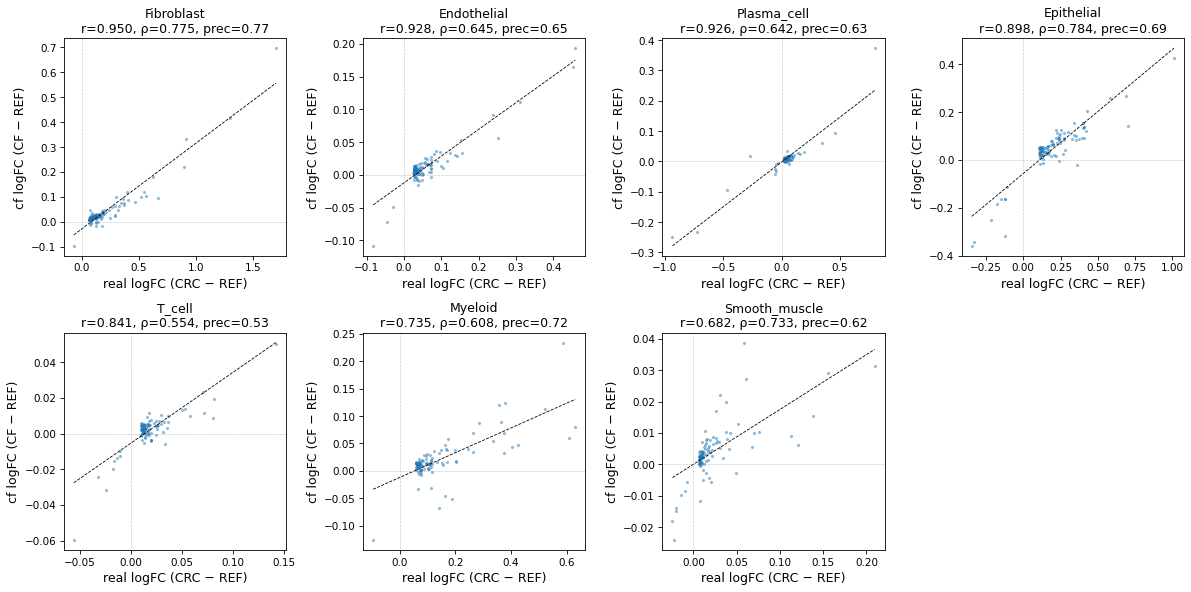

In [39]:
n_cts = len(summary)
ncols = 4
nrows = (n_cts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (_, row) in enumerate(summary.iterrows()):
    ct = row["cell_type"]
    ax = axes[i]

    real = logfcs[ct]["real_logfc"]
    cf   = logfcs[ct]["cf_logfc"]
    mask = logfcs[ct]["top_n_mask"]
    if mask is not None:
        real, cf = real[mask], cf[mask]

    ax.scatter(real, cf, s=4, alpha=0.4)

    # Per-panel OLS fit line
    m, b = np.polyfit(real, cf, 1)
    x_lo, x_hi = real.min(), real.max()
    ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], color='k', lw=0.8, ls='--')

    # Zero crossings
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')

    ax.set_xlabel('real logFC (CRC − REF)', fontsize=12)
    ax.set_ylabel('cf logFC (CF − REF)', fontsize=12)
    ax.set_title(
        f"{ct}\n"
        f"r={row['pearson_r']:.3f}, ρ={row['spearman_r']:.3f}, prec={row['precision']:.2f}",
        fontsize=12,
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [40]:
model.validation_indices_

array([82149, 42807, 70264, ..., 76776, 76332, 10632])

In [41]:
stop

NameError: name 'stop' is not defined

In [ ]:
def spatial_coherence_score(X, labels, k=5):
    X = np.asarray(X)
    labels = np.asarray(labels)

    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, indices = nbrs.kneighbors(X)

    # exclude each point itself (indices[:,0])
    indices = indices[:, 1:]
    
    same_cluster_counts = np.sum(labels[indices] == labels[:, None], axis=1)
    scs = np.mean(same_cluster_counts / k)
    return scs


In [ ]:
# Nearest Neighbours and Leiden Clustering
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata, neighbors_key='neighbors')

In [ ]:
sc.pl.spatial(adata, color=['leiden_s'], spot_size=50)

In [ ]:

sc.tl.leiden(adata, key_added='leiden_s', resolution=0.4)

spatial_coherence_score(adata.obsm['spatial'], adata.obs['leiden_s'], k=n_neighbors) # NOTE: most sensible metric imho
# NOTE: worse than when using spatial_x

In [ ]:
def compute_spatial_metrics(adata, label_key: str, coord_key: str = 'spatial', exclude_labels=None) -> float:
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
    import pandas as pd
    from scipy.spatial.distance import pdist, squareform

    adata.obs[label_key] = adata.obs[label_key].astype('category')
    
    if exclude_labels is not None:
        mask = ~adata.obs[label_key].isin(exclude_labels)
        ad = adata[mask].copy()
    else:
        ad = adata

    labels = ad.obs[label_key].cat.codes.values
    spatial_coords = ad.obsm[coord_key]

    mean_asw = silhouette_score(X=spatial_coords, labels=labels, metric='euclidean')
    db_score = davies_bouldin_score(X=spatial_coords, labels=labels)
    ch_score = calinski_harabasz_score(X=spatial_coords, labels=labels)
    
    samples_asw = silhouette_samples(X=spatial_coords, labels=labels, metric='euclidean')
    
    df = pd.DataFrame(index=ad.obs_names, data={f'spatial_asw_{label_key}': samples_asw})
    asw_by_label = df.groupby(ad.obs[label_key])[f'spatial_asw_{label_key}'].mean().round(3)
    asw_by_label.index.name = label_key
    asw_by_label = asw_by_label.to_dict()
    
    global_scores = {
        'asw ↑': round(mean_asw, 3),
        'db_score ↓': round(db_score, 3),
        'ch_score ↑': round(ch_score, 3)
    }
    
    return global_scores, asw_by_label

In [ ]:
# compute_spatial_metrics(adata, label_key='leiden_s', coord_key='spatial') # NOTE: takes forever